In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
res_dir = '/project/diana8/cwirth/HELIOS/output/TRAPPIST-1c_EH3'

In [4]:
spec_downflux = pd.read_csv(f'{res_dir}/TRAPPIST-1c_EH3_spec_downflux.dat', sep='\\s+', skiprows=2)
spec_upflux = pd.read_csv(f'{res_dir}/TRAPPIST-1c_EH3_spec_upflux.dat', sep='\\s+', skiprows=2)

In [5]:
spec_upflux

,bin,cent_lambda[um],low_int_lambda[um],delta_lambda[um],F_up[0],F_up[1],F_up[2],F_up[3],F_up[4],F_up[5],...,F_up[62],F_up[63],F_up[64],F_up[65],F_up[66],F_up[67],F_up[68],F_up[69],F_up[70],F_up[71]
0,0,0.246440,0.244000,0.004880,37149.07520,46615.95790,54172.89520,60144.56110,64932.11260,68786.25750,...,81949.99300,81950.00400,81950.01280,81950.01990,81950.02550,81950.03000,81950.03350,81950.03630,81950.03860,81950.04040
1,1,0.251369,0.248880,0.004978,53517.03280,66010.13040,75982.75350,83863.35450,90181.32580,95267.51470,...,112639.41600,112639.43100,112639.44200,112639.45200,112639.45900,112639.46500,112639.47000,112639.47300,112639.47600,112639.47900
2,2,0.256396,0.253858,0.005077,76332.43230,92660.80480,105694.94900,115994.84000,124252.39100,130900.01300,...,153605.21900,153605.23800,153605.25300,153605.26600,153605.27500,153605.28300,153605.28900,153605.29400,153605.29800,153605.30100
3,3,0.261524,0.258935,0.005179,107821.87800,128962.99800,145838.93700,159174.70500,169866.16400,178473.17500,...,207871.06100,207871.08500,207871.10500,207871.12100,207871.13300,207871.14300,207871.15100,207871.15800,207871.16300,207871.16700
4,4,0.266755,0.264113,0.005282,150865.59100,177987.82500,199638.21100,216746.85900,230463.09500,241505.16700,...,279220.61600,279220.64700,279220.67200,279220.69300,279220.70900,279220.72200,279220.73200,279220.74000,279220.74600,279220.75100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,380,456.852988,452.329691,9.046594,2860.77995,2866.73953,2855.95135,2833.48287,2803.96647,2775.98157,...,2492.17895,2492.17895,2492.17895,2492.17895,2492.17895,2492.17895,2492.17895,2492.17895,2492.17895,2492.17895
381,381,465.990048,461.376285,9.227526,2583.33498,2601.98925,2604.85102,2596.87280,2580.37520,2562.41257,...,2336.93196,2336.93196,2336.93196,2336.93196,2336.93196,2336.93196,2336.93196,2336.93196,2336.93196,2336.93196
382,382,475.309849,470.603811,9.412076,2398.17211,2415.59723,2417.65700,2409.78027,2393.92044,2376.53581,...,2164.55464,2164.55464,2164.55464,2164.55464,2164.55464,2164.55464,2164.55464,2164.55464,2164.55464,2164.55464
383,383,484.816046,480.015887,9.600318,2282.13866,2283.32210,2271.24557,2252.02644,2229.51477,2209.65123,...,2011.66462,2011.66462,2011.66462,2011.66462,2011.66462,2011.66462,2011.66462,2011.66462,2011.66462,2011.66462


In [6]:
int_flux = pd.read_csv(f'{res_dir}/TRAPPIST-1c_EH3_integrated_flux.dat', sep='\\s+', skiprows=2)

In [7]:
int_flux

,interface,press.[10^-6bar],F_down,F_up,F_net,F_dir,delta_F_net,(layer,quantity),F_net_conv,F_add_heat,F_intern
0,0,500000.000000,4049410.0,4049460.0,45.9374,0,0.00999367,0,0,45.93,NaN,NaN
1,1,401744.000000,3792050.0,3792090.0,45.9274,0,-0.00246772,0,0,NaN,NaN,NaN
2,2,322796.000000,3554400.0,3554440.0,45.9299,0,0.00281905,0,0,NaN,NaN,NaN
3,3,259363.000000,3251920.0,3251970.0,45.9271,0,-0.00116558,0,0,NaN,NaN,NaN
4,4,208395.000000,2949920.0,2949960.0,45.9282,0,0.00294866,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
67,67,0.215067,1122100.0,1122150.0,45.9202,0,6.67991e-07,0,0,NaN,NaN,NaN
68,68,0.172803,1122070.0,1122120.0,45.9202,0,-6.04196e-07,0,0,NaN,NaN,NaN
69,69,0.138845,1122040.0,1122080.0,45.9202,0,3.88594e-07,0,0,NaN,NaN,NaN
70,70,0.111560,1122010.0,1122060.0,45.9202,0,4.80097e-07,0,0,NaN,NaN,NaN


In [8]:
int_flux['F_down'][71]

np.float64(1122000.0)

In [9]:
tp = pd.read_csv(f'{res_dir}/TRAPPIST-1c_EH3_tp.dat', sep='\\s+', skiprows=1)

In [10]:
# convert column to numeric, non-numeric entries become NaN
height = pd.to_numeric(tp['height.of.layer[cm]'], errors='coerce')
tp['height.of.layer[cm]'] = height

In [11]:
tp

,layer,temp.[K],press.[10^-6bar],altitude[cm],height.of.layer[cm],"conv.unstable?[1:yes,0:no]","conv.lapse-rate?[1:yes,0:no]",pl.eff.temp.[K]
0,BOA,516.949,500000.000000,0.0,NaN,0,0,375.059
1,0,508.336,448187.000000,7669050.0,15338100.0,0,0,NaN
2,1,499.335,360113.000000,22466100.0,14255900.0,0,0,NaN
3,2,488.883,289346.000000,33513500.0,7838960.0,0,0,NaN
4,3,475.235,232486.000000,39982700.0,5099410.0,0,0,NaN
...,...,...,...,...,...,...,...,...
67,66,313.042,0.239929,308730000.0,2878330.0,0,0,NaN
68,67,311.064,0.192780,311756000.0,3173320.0,0,0,NaN
69,68,309.132,0.154897,315108000.0,3531170.0,0,0,NaN
70,69,307.914,0.124457,318776000.0,3804620.0,0,0,NaN


In [12]:
flux_total_up = (spec_upflux['F_up[71]']*spec_upflux['delta_lambda[um]']/1e4).sum()

In [13]:
flux_total_up-int_flux['F_up'][71]

np.float64(2.9231980710756034)

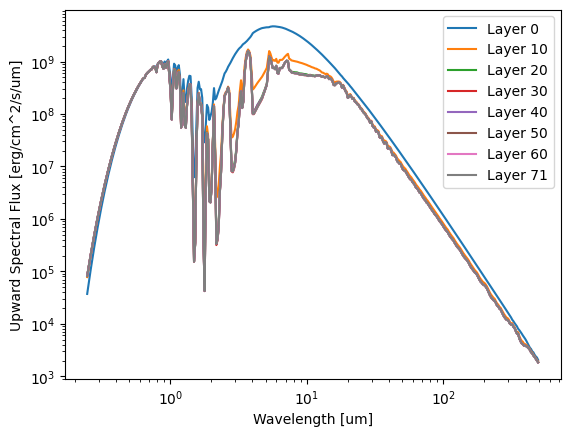

In [26]:
layers = [0, 10, 20, 30, 40, 50, 60, 71]
for layer in layers:
    plt.plot(spec_upflux['cent_lambda[um]'], spec_upflux[f'F_up[{layer}]'], label=f'Layer {layer}')

plt.xlabel('Wavelength [um]')
plt.ylabel('Upward Spectral Flux [erg/cm^2/s/um]')
plt.yscale('log')
plt.xscale('log')
plt.legend()

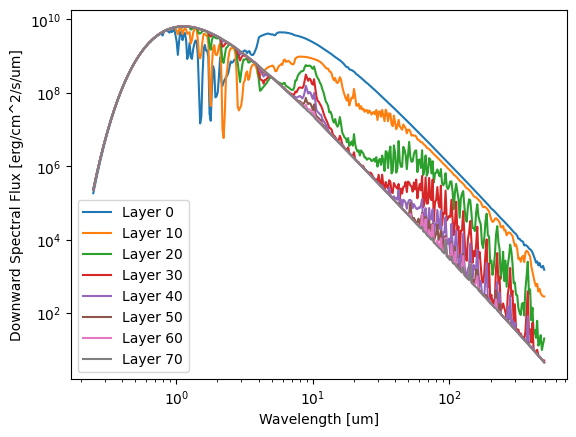

In [24]:
layers = [0, 10, 20, 30, 40, 50, 60, 70]
for layer in layers:
    plt.plot(spec_downflux['cent_lambda[um]'], spec_downflux[f'F_down[{layer}]'], label=f'Layer {layer}')

plt.xlabel('Wavelength [um]')
plt.ylabel('Downward Spectral Flux [erg/cm^2/s/um]')
plt.yscale('log')
plt.xscale('log')
plt.legend()

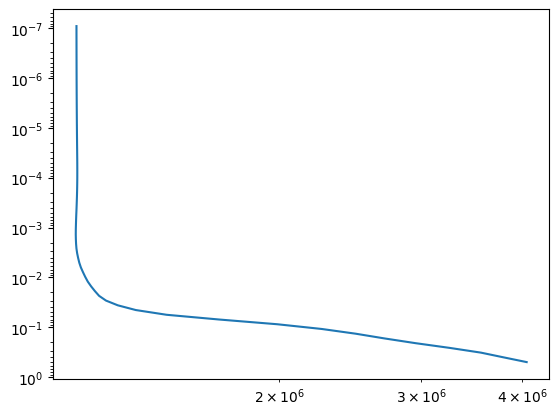

In [16]:
plt.plot(int_flux['F_up'], int_flux['press.[10^-6bar]']/10**6, label='Integrated Flux Up')
plt.yscale('log')
plt.xscale('log')
plt.gca().invert_yaxis()

In [17]:
flux_to_night = int_flux['F_down'][71] * (0.5-0.3655)/0.3655

In [18]:
#distribute this flux evenly from 10^-2 to 10^-7 bar
press_col_bar = tp['press.[10^-6bar]'][1:]/10**6  # in bar
press_mask = (press_col_bar >= 1e-7) & (press_col_bar <= 1e0)
layer_height = tp['height.of.layer[cm]'][1:]

In [19]:
heating_rate = np.zeros_like(layer_height)
heating_rate[press_mask] = flux_to_night / layer_height[press_mask]

In [20]:
heating_rate

array([0.02691883, 0.0289623 , 0.05267073, 0.08096696, 0.10328238,
       0.11910233, 0.16705119, 0.26504453, 0.40948906, 0.3757314 ,
       0.24613185, 0.16929374, 0.11268384, 0.07825429, 0.06079813,
       0.04476505, 0.04507159, 0.04531427, 0.04554752, 0.04582139,
       0.04605112, 0.04620934, 0.04638455, 0.04651912, 0.04657144,
       0.04687913, 0.04736785, 0.04781315, 0.04818522, 0.04806999,
       0.04793883, 0.04778575, 0.05178453, 0.05886859, 0.0661661 ,
       0.07427062, 0.08954592, 0.10489585, 0.12020254, 0.15946197,
       0.21587901, 0.27076295, 0.32399554, 0.38133933, 0.4357175 ,
       0.48737166, 0.49489767, 0.46936366, 0.44417066, 0.41978712,
       0.40125924, 0.38271435, 0.36407573, 0.34318036, 0.32071877,
       0.29882731, 0.27767529, 0.25369355, 0.2311779 , 0.21026661,
       0.19697993, 0.189524  , 0.18201941, 0.17405684, 0.16527447,
       0.15519144, 0.14344558, 0.13011096, 0.11692547, 0.10852167,
       0.11647326])

In [21]:
len(heating_rate)

71

In [22]:
heating_file_df = pd.DataFrame({
    'pressure': press_col_bar,
    'heating_rate': heating_rate
})

In [34]:
#print heating file df to file
heating_file_df.to_csv(f'input/heating/TRAPPIST-1c_EH3_nightside_heating_rate.dat', sep='\t', index=False)

In [1]:
import h5py

In [27]:
spec_TOA_day = spec_upflux['F_up[71]']

In [28]:
spec_TOA_day

0       81950.04040
1      112639.47900
2      153605.30100
3      207871.16700
4      279220.75100
           ...     
380      2492.17895
381      2336.93196
382      2164.55464
383      2011.66462
384      1846.72032
Name: F_up[71], Length: 385, dtype: float64

In [29]:
file_compare = h5py.File('star_tool/output/WASP15.h5', 'r')

In [40]:
file_compare['r50_kdistr']['lambda'][:]

array([2.46440000e-05, 2.51368800e-05, 2.56396176e-05, 2.61524100e-05,
       2.66754582e-05, 2.72089673e-05, 2.77531467e-05, 2.83082096e-05,
       2.88743738e-05, 2.94518613e-05, 3.00408985e-05, 3.06417165e-05,
       3.12545508e-05, 3.18796418e-05, 3.25172346e-05, 3.31675793e-05,
       3.38309309e-05, 3.45075495e-05, 3.51977005e-05, 3.59016545e-05,
       3.66196876e-05, 3.73520814e-05, 3.80991230e-05, 3.88611055e-05,
       3.96383276e-05, 4.04310941e-05, 4.12397160e-05, 4.20645103e-05,
       4.29058005e-05, 4.37639165e-05, 4.46391949e-05, 4.55319788e-05,
       4.64426184e-05, 4.73714707e-05, 4.83189001e-05, 4.92852781e-05,
       5.02709837e-05, 5.12764034e-05, 5.23019314e-05, 5.33479701e-05,
       5.44149295e-05, 5.55032281e-05, 5.66132926e-05, 5.77455585e-05,
       5.89004696e-05, 6.00784790e-05, 6.12800486e-05, 6.25056496e-05,
       6.37557626e-05, 6.50308778e-05, 6.63314954e-05, 6.76581253e-05,
       6.90112878e-05, 7.03915136e-05, 7.17993438e-05, 7.32353307e-05,
      

In [ ]:
#write spec_TOA_day to file
file_out = h5py.File('input/spectra/TRAPPIST-1c_EH3_TOA_day_spectrum.h5', 'w')
file_out.create_dataset('wavelength_um', data=spec_upflux['cent_lambda[um]'])
file_out.create_dataset('flux_erg_cm2_s_um', data=spec_TOA